In [3]:
# DSC 530 Final Project: Exploratory Data Analysis on Coronavirus Dataset
# Mahad Farah
# 06/01/25


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from scipy import stats

# Load dataset
df = pd.read_csv("covid_19_clean_complete.csv")

# Preview dataset
print(df.head())


  Province/State Country/Region       Lat       Long        Date  Confirmed  \
0            NaN    Afghanistan  33.93911  67.709953  2020-01-22          0   
1            NaN        Albania  41.15330  20.168300  2020-01-22          0   
2            NaN        Algeria  28.03390   1.659600  2020-01-22          0   
3            NaN        Andorra  42.50630   1.521800  2020-01-22          0   
4            NaN         Angola -11.20270  17.873900  2020-01-22          0   

   Deaths  Recovered  Active             WHO Region  
0       0          0       0  Eastern Mediterranean  
1       0          0       0                 Europe  
2       0          0       0                 Africa  
3       0          0       0                 Europe  
4       0          0       0                 Africa  


In [4]:
# 2. Data Cleaning and Preparation

# Drop irrelevant columns and check missing data

df.drop(['Province/State'], axis=1, inplace=True)
df['Date'] = pd.to_datetime(df['Date'])
df.fillna(0, inplace=True)

# Feature engineering: Active Cases
df['Active'] = df['Confirmed'] - df['Deaths'] - df['Recovered']


In [5]:
# 3. Summary Statistics

print(df.describe())


                Lat          Long     Confirmed         Deaths     Recovered  \
count  49068.000000  49068.000000  4.906800e+04   49068.000000  4.906800e+04   
mean      21.433730     23.528236  1.688490e+04     884.179160  7.915713e+03   
std       24.950320     70.442740  1.273002e+05    6313.584411  5.480092e+04   
min      -51.796300   -135.000000  0.000000e+00       0.000000  0.000000e+00   
25%        7.873054    -15.310100  4.000000e+00       0.000000  0.000000e+00   
50%       23.634500     21.745300  1.680000e+02       2.000000  2.900000e+01   
75%       41.204380     80.771797  1.518250e+03      30.000000  6.660000e+02   
max       71.706900    178.065000  4.290259e+06  148011.000000  1.846641e+06   

             Active  
count  4.906800e+04  
mean   8.085012e+03  
std    7.625890e+04  
min   -1.400000e+01  
25%    0.000000e+00  
50%    2.600000e+01  
75%    6.060000e+02  
max    2.816444e+06  


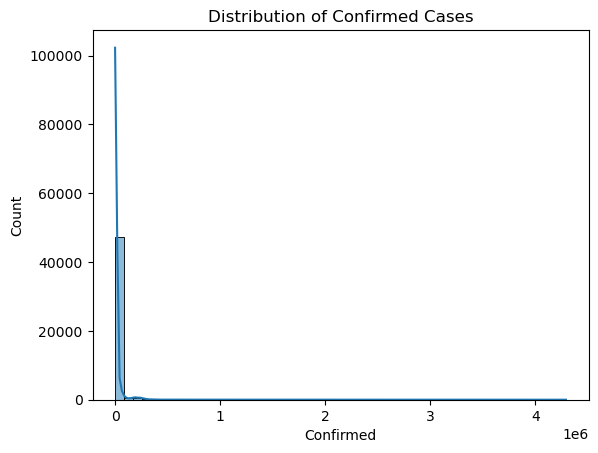

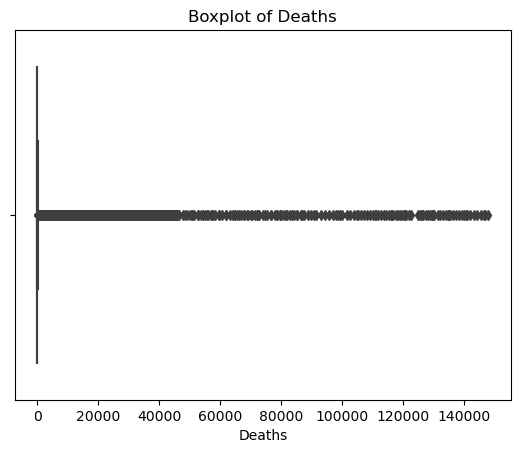

In [6]:
# 4. Univariate Analysis

# Histogram
sns.histplot(df['Confirmed'], bins=50, kde=True)
plt.title('Distribution of Confirmed Cases')
plt.show()

# Boxplot for outliers
sns.boxplot(x=df['Deaths'])
plt.title('Boxplot of Deaths')
plt.show()


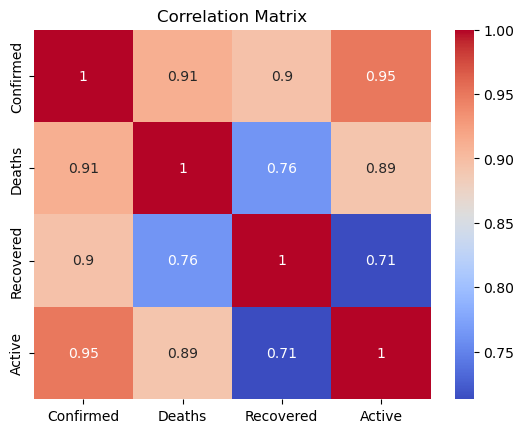

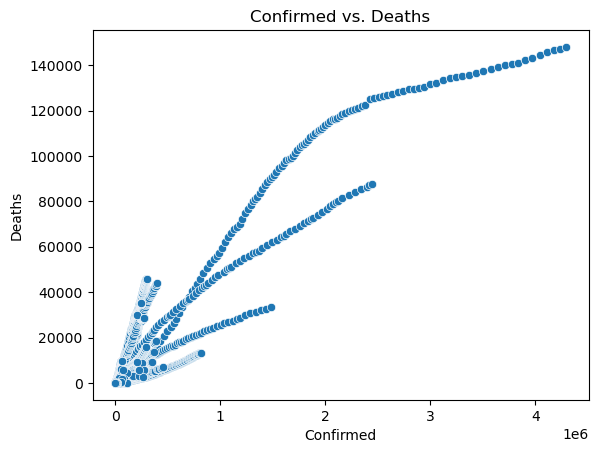

In [7]:
# 5. Bivariate Analysis

# Correlation matrix
corr = df[['Confirmed', 'Deaths', 'Recovered', 'Active']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Scatterplot
sns.scatterplot(data=df, x='Confirmed', y='Deaths')
plt.title('Confirmed vs. Deaths')
plt.show()


In [8]:
# 6. Statistical Testing

# Hypothesis: Confirmed cases have a statistically significant correlation with Deaths
r, p = stats.pearsonr(df['Confirmed'], df['Deaths'])
print(f"Pearson r: {r}, p-value: {p}")



Pearson r: 0.9123609953778936, p-value: 0.0


In [9]:
# 7. Regression Analysis

X = df[['Confirmed', 'Recovered']]
y = df['Deaths']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg = LinearRegression()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred))
print("Regression Coefficients:", reg.coef_)


Linear Regression MSE: 6175189.943377741
Regression Coefficients: [ 0.05804573 -0.03238809]


In [10]:
# 8. Classification Model (Logistic Regression)
# Binary variable: High Death (>1000 deaths)
df['High_Death'] = np.where(df['Deaths'] > 1000, 1, 0)
X = df[['Confirmed', 'Recovered']]
y = df['High_Death']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      9148
           1       0.88      0.80      0.84       666

    accuracy                           0.98      9814
   macro avg       0.93      0.89      0.91      9814
weighted avg       0.98      0.98      0.98      9814



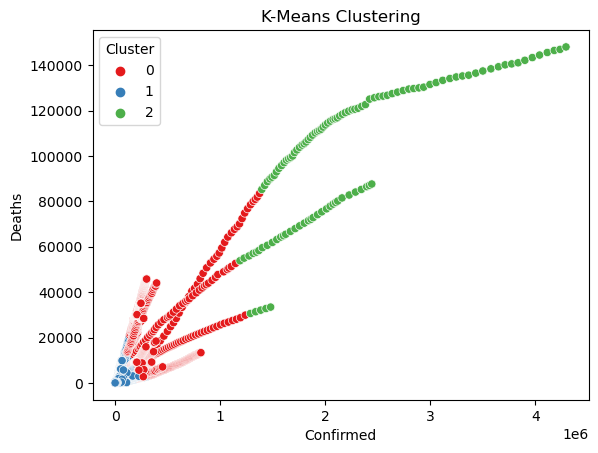

In [11]:
# 9. Clustering Analysis

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[['Confirmed', 'Deaths', 'Recovered']])

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(df_scaled)
sns.scatterplot(x=df['Confirmed'], y=df['Deaths'], hue=df['Cluster'], palette='Set1')
plt.title("K-Means Clustering")
plt.show()
